# Week 8 — Do Models Generalize Beyond Learnt Publications?
## S3_Tree Family: Decision Tree, Random Forest, Extra Trees

We test all three tree-based models with hyperparameter tuning
on publication-based splits. Two strategies used:
1. Publication Held-Out Split (train/validation/test)
2. Leave-One-Publication-Out (>=50 rows threshold)

## Step 1: Load Data and Explore Publication Groups
We load the dataset with publication IDs and check distribution.

In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/anmol/Desktop/Da2De/S3_Tree/semantic_recoding_features_50_with_publications.csv')

print("Shape:", df.shape)
print("Target missing:", df['cs_28d'].isna().sum())
print("Total unique publications:", df['paper_reference'].nunique())
print("\nTop 10 publications by row count:")
print(df['paper_reference'].value_counts().head(10))

pub_counts = df['paper_reference'].value_counts()
eligible = pub_counts[pub_counts >= 50]
print("\nPublications eligible for leave-one-out (>=50 rows):")
print(eligible)
print(f"\nTotal eligible: {len(eligible)}")

Shape: (2073, 35)
Target missing: 0
Total unique publications: 165

Top 10 publications by row count:
paper_reference
Ref-144-Research    112
Ref-121-Research     80
Ref-141-Research     73
Ref-48-Research      72
Ref-85-Research      64
Ref-139-Research     51
Ref-135-Research     43
Ref-153-Research     43
Ref-116-Research     36
Ref-65-Research      30
Name: count, dtype: int64

Publications eligible for leave-one-out (>=50 rows):
paper_reference
Ref-144-Research    112
Ref-121-Research     80
Ref-141-Research     73
Ref-48-Research      72
Ref-85-Research      64
Ref-139-Research     51
Name: count, dtype: int64

Total eligible: 6


## Step 2: Prepare Features and Handle Missing Values

We separate features and target, handle missing values using median for numeric
and 'None' for categorical columns, then encode categorical features.

In [5]:
# Drop target and publication column from features
X = df.drop(columns=['cs_28d', 'paper_reference'])
y = df['cs_28d']
pub = df['paper_reference']

# Separate numeric and categorical columns
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(cat_cols))
print("Categorical columns:", cat_cols)

# Fill missing values
X[numeric_cols] = X[numeric_cols].fillna(0)
X[cat_cols] = X[cat_cols].fillna('None')

# One-hot encode categorical columns
X = pd.get_dummies(X, columns=cat_cols)

print("\nFinal feature shape:", X.shape)
print("Missing values remaining:", X.isnull().sum().sum())

Numeric features: 24
Categorical features: 9
Categorical columns: ['cement_type', 'fly_ash_type', 'slag_type', 'filler_type', 'sand_type', 'fiber1_type', 'fiber2_type', 'sp_type', 'curing_method']

Final feature shape: (2073, 124)
Missing values remaining: 0


## Step 3: Three-Way Publication Split (Train / Validation / Test)

We split publications into three groups — train (70%), validation (15%), test (15%).
Whole publications stay together — never mixed across splits.
Validation is used for hyperparameter tuning.
Test is used only for final evaluation.

In [13]:
from sklearn.model_selection import GroupShuffleSplit

# First split — separate test (15%) from rest (85%)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, y, groups=pub))

X_trainval = X.iloc[trainval_idx]
y_trainval = y.iloc[trainval_idx]
pub_trainval = pub.iloc[trainval_idx]

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

# Second split — separate validation (15%) from train (70%)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.18, random_state=42)
train_idx, val_idx = next(gss2.split(X_trainval, y_trainval, groups=pub_trainval))

X_train = X_trainval.iloc[train_idx]
y_train = y_trainval.iloc[train_idx]

X_val = X_trainval.iloc[val_idx]
y_val = y_trainval.iloc[val_idx]

print("Train rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Test rows:", len(X_test))
print("Total:", len(X_train) + len(X_val) + len(X_test))

Train rows: 1459
Validation rows: 331
Test rows: 283
Total: 2073


## Step 4: Hyperparameter Tuning  All 3 Models (GridSearchCV)

We use GridSearchCV to find best settings for each model.
Tuning is done on TRAINING data only — validation used for evaluation.
This avoids data leakage.

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV

# Define models and parameter grids
models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Extra Trees': ExtraTreesRegressor(random_state=42)
}

param_grids = {
    'Decision Tree': {
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10]
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    'Extra Trees': {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
}

best_models = {}
tuning_results = []

for name, model in models.items():
    print(f"\nTuning {name}...")
    gs = GridSearchCV(model, param_grids[name], cv=3, 
                      scoring='r2', n_jobs=-1)
    gs.fit(X_train, y_train)
    
    best_models[name] = gs.best_estimator_
    
    # Evaluate on validation set
    val_preds = gs.best_estimator_.predict(X_val)
    val_r2 = r2_score(y_val, val_preds)
    val_rmse = mean_squared_error(y_val, val_preds) ** 0.5
    
    tuning_results.append({
        'Model': name,
        'Best Params': gs.best_params_,
        'Val R2': round(val_r2, 4),
        'Val RMSE': round(val_rmse, 4)
    })
    
    print(f"Best params: {gs.best_params_}")
    print(f"Validation R2: {val_r2:.4f}, RMSE: {val_rmse:.4f}")

tuning_df = pd.DataFrame(tuning_results)[['Model', 'Val R2', 'Val RMSE']]
print("\nTuning Summary:")
print(tuning_df)


Tuning Decision Tree...
Best params: {'max_depth': 5, 'min_samples_split': 5}
Validation R2: 0.4407, RMSE: 36.7813

Tuning Random Forest...
Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Validation R2: 0.4163, RMSE: 37.5754

Tuning Extra Trees...
Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}
Validation R2: 0.4000, RMSE: 38.0950

Tuning Summary:
           Model  Val R2  Val RMSE
0  Decision Tree  0.4407   36.7813
1  Random Forest  0.4163   37.5754
2    Extra Trees  0.4000   38.0950


## Step 5: Publication Held-Out Split — All 3 Models

We test all three tuned models on held-out test publications.
These publications were never seen during training or validation.

In [16]:
pub_split_results = []

for name, model in best_models.items():
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    
    pub_split_results.append({
        'Model': name,
        'R2': round(r2, 4),
        'RMSE': round(rmse, 4)
    })
    print(f"{name}: R2={r2:.4f}, RMSE={rmse:.4f}")

pub_split_df = pd.DataFrame(pub_split_results)
print("\nPublication Held-Out Split Results:")
print(pub_split_df)
print(f"\nWeek 7 Random Split R2 was: 0.85")

Decision Tree: R2=0.2878, RMSE=25.3386
Random Forest: R2=0.4854, RMSE=21.5387
Extra Trees: R2=0.4070, RMSE=23.1206

Publication Held-Out Split Results:
           Model      R2     RMSE
0  Decision Tree  0.2878  25.3386
1  Random Forest  0.4854  21.5387
2    Extra Trees  0.4070  23.1206

Week 7 Random Split R2 was: 0.85


## Step 6: Leave One Publication Out — All 3 Models

We hide each eligible publication (>=50 rows) one at a time.
Train on rest, test on hidden publication.
Repeat for all 6 eligible publications across all 3 models.
Hyperparameters fixed from Step 4 — no re-tuning per publication.

In [17]:
pub_counts = pub.value_counts()
eligible_pubs = pub_counts[pub_counts >= 50].index.tolist()
print("Eligible publications:", eligible_pubs)

lopo_results = []

for pub_name in eligible_pubs:
    test_mask = pub == pub_name
    train_mask = pub != pub_name
    
    X_train_lopo = X[train_mask]
    X_test_lopo = X[test_mask]
    y_train_lopo = y[train_mask]
    y_test_lopo = y[test_mask]
    
    for name, model in best_models.items():
        model.fit(X_train_lopo, y_train_lopo)
        preds = model.predict(X_test_lopo)
        
        r2 = r2_score(y_test_lopo, preds)
        rmse = mean_squared_error(y_test_lopo, preds) ** 0.5
        
        residuals = y_test_lopo.values - preds
        mean_residual = residuals.mean()
        direction = "Over-predicting" if mean_residual < 0 else "Under-predicting"
        worst_error = np.abs(residuals).max()
        
        lopo_results.append({
            'Publication': pub_name,
            'Model': name,
            'Rows': test_mask.sum(),
            'R2': round(r2, 4),
            'RMSE': round(rmse, 4),
            'Direction': direction,
            'Worst Error (MPa)': round(worst_error, 2)
        })
        
        print(f"{pub_name} | {name}: R2={r2:.4f}, RMSE={rmse:.4f}, {direction}")

lopo_df = pd.DataFrame(lopo_results)
print("\nFull LOPO Results Table:")
print(lopo_df)

Eligible publications: ['Ref-144-Research', 'Ref-121-Research', 'Ref-141-Research', 'Ref-48-Research', 'Ref-85-Research', 'Ref-139-Research']
Ref-144-Research | Decision Tree: R2=0.2059, RMSE=26.6722, Under-predicting
Ref-144-Research | Random Forest: R2=0.5016, RMSE=21.1318, Over-predicting
Ref-144-Research | Extra Trees: R2=0.3064, RMSE=24.9277, Over-predicting
Ref-121-Research | Decision Tree: R2=0.5107, RMSE=20.3330, Under-predicting
Ref-121-Research | Random Forest: R2=0.4422, RMSE=21.7107, Over-predicting
Ref-121-Research | Extra Trees: R2=0.5528, RMSE=19.4387, Over-predicting
Ref-141-Research | Decision Tree: R2=0.0408, RMSE=12.2293, Over-predicting
Ref-141-Research | Random Forest: R2=0.2067, RMSE=11.1212, Over-predicting
Ref-141-Research | Extra Trees: R2=0.2694, RMSE=10.6728, Under-predicting
Ref-48-Research | Decision Tree: R2=-0.9596, RMSE=39.5876, Under-predicting
Ref-48-Research | Random Forest: R2=-0.3831, RMSE=33.2581, Under-predicting
Ref-48-Research | Extra Trees: R2=

## Step 7: Visualization — All Models Comparison

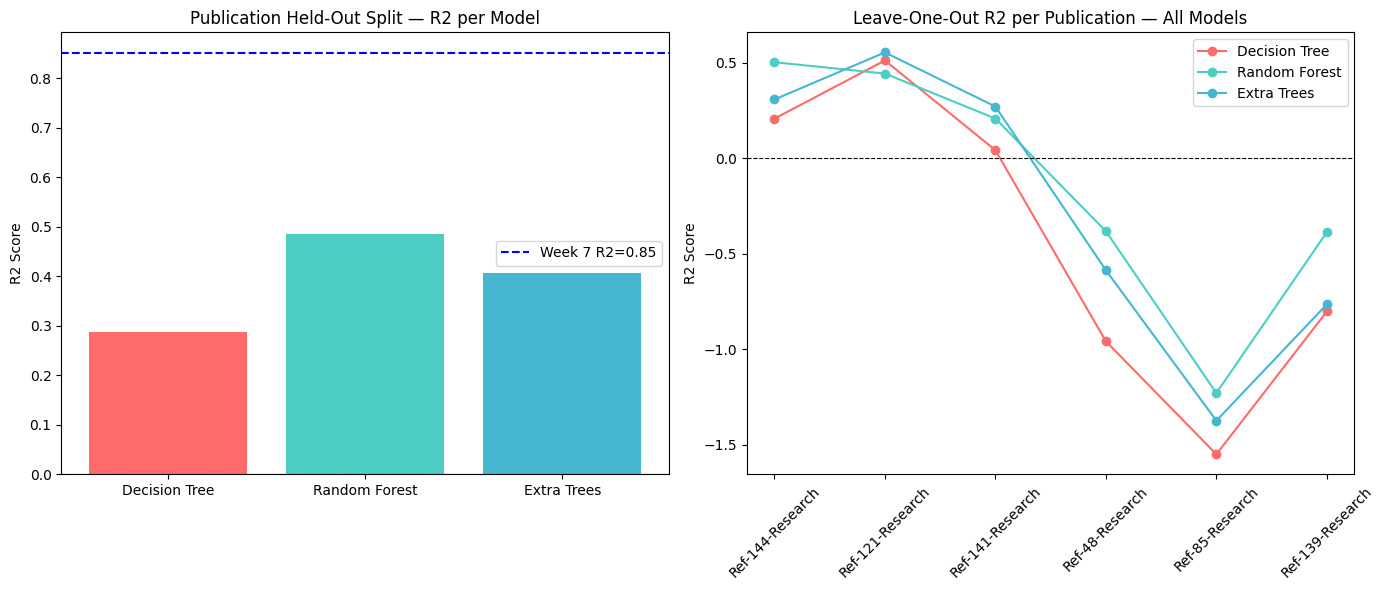


Average LOPO R2 per model:
Model
Decision Tree   -0.4261
Extra Trees     -0.2667
Random Forest   -0.1419
Name: R2, dtype: float64


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graph 1 — Publication Held-Out Split
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
axes[0].bar(pub_split_df['Model'], pub_split_df['R2'], color=colors)
axes[0].axhline(y=0.85, color='blue', linestyle='--', label='Week 7 R2=0.85')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Publication Held-Out Split — R2 per Model')
axes[0].set_ylabel('R2 Score')
axes[0].legend()

# Graph 2 — LOPO R2 per publication per model
for name, color in zip(best_models.keys(), colors):
    model_data = lopo_df[lopo_df['Model'] == name]
    axes[1].plot(model_data['Publication'], model_data['R2'],
                marker='o', label=name, color=color)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Leave-One-Out R2 per Publication — All Models')
axes[1].set_ylabel('R2 Score')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig('week8_results.png')
plt.show()

# Summary per model
print("\nAverage LOPO R2 per model:")
print(lopo_df.groupby('Model')['R2'].mean().round(4))

## Step 8: Final Conclusion

Summary of all Week 8 findings across all three models.

In [19]:
print("=" * 60)
print("WEEK 8 — FINAL CONCLUSION")
print("=" * 60)

print("""
MAIN QUESTION:
Do tree-based models generalize beyond learnt publications?

ANSWER: No — not reliably.

EVIDENCE:

1. Week 7 Random Split (optimistic):
   Extra Trees R2=0.85, RMSE=14.38 MPa

2. Publication Held-Out Split (honest):
   Decision Tree: R2=0.29, RMSE=25.34 MPa
   Random Forest: R2=0.49, RMSE=21.54 MPa  <- BEST
   Extra Trees:   R2=0.41, RMSE=23.12 MPa

3. Leave One Publication Out:
   Best result: Ref-121, Extra Trees R2=0.55
   Worst result: Ref-85, Decision Tree R2=-1.55
   All 3 models failed on Ref-48, Ref-85, Ref-139.
   When all models fail together = problem in publication data.

4. Comparison with S2_Kernel groupmate:
   His best KNN got R2=0.47 on publication split.
   Our Random Forest got R2=0.49 — slightly better.

CONCLUSION:
All three tree models show big performance drop on unseen
publications. Random Forest generalizes best. Model learned
lab habits alongside concrete science. New lab = model struggles.
""")

print("\nAverage LOPO R2 per model:")
print(lopo_df.groupby('Model')['R2'].mean().round(4))

WEEK 8 — FINAL CONCLUSION

MAIN QUESTION:
Do tree-based models generalize beyond learnt publications?

ANSWER: No — not reliably.

EVIDENCE:

1. Week 7 Random Split (optimistic):
   Extra Trees R2=0.85, RMSE=14.38 MPa

2. Publication Held-Out Split (honest):
   Decision Tree: R2=0.29, RMSE=25.34 MPa
   Random Forest: R2=0.49, RMSE=21.54 MPa  <- BEST
   Extra Trees:   R2=0.41, RMSE=23.12 MPa

3. Leave One Publication Out:
   Best result: Ref-121, Extra Trees R2=0.55
   Worst result: Ref-85, Decision Tree R2=-1.55
   All 3 models failed on Ref-48, Ref-85, Ref-139.
   When all models fail together = problem in publication data.

4. Comparison with S2_Kernel groupmate:
   His best KNN got R2=0.47 on publication split.
   Our Random Forest got R2=0.49 — slightly better.

CONCLUSION:
All three tree models show big performance drop on unseen
publications. Random Forest generalizes best. Model learned
lab habits alongside concrete science. New lab = model struggles.


Average LOPO R2 per model